# Modeling — KNN Regressor
## Prediksi Hasil Panen Tanaman Berbasis Data Iklim dan Nutrisi Tanaman

| Informasi | Detail |
|-----------|--------|
| Algoritma | KNN Regressor |
| Target | `yield_hg_ha` (hasil panen dalam hg/ha) |
| Fitur | area, item, year, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp |
| Data Train | X_train.csv / y_train.csv |
| Data Test | X_test.csv / y_test.csv |

---

## Import library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

X_train = pd.read_csv('output/X_train.csv')
X_test  = pd.read_csv('output/X_test.csv')
y_train = pd.read_csv('output/y_train.csv').squeeze()
y_test  = pd.read_csv('output/y_test.csv').squeeze()

print('Data berhasil dimuat.')
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

## Training Model KNN Regressor

In [ ]:
model = KNeighborsRegressor(
    n_neighbors=5,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None
    )
model.fit(X_train, y_train)

In [16]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
print(f'MAE (Train): {mae_train:.4f}')
mae_test = mean_absolute_error(y_test, y_pred_test)
print(f'MAE (Test) : {mae_test:.4f}')
rmse_train = root_mean_squared_error(y_train, y_pred_train)
print(f'RMSE (Train): {rmse_train:.4f}')
rmse_test = root_mean_squared_error(y_test, y_pred_test)
print(f'RMSE (Test) : {rmse_test:.4f}')
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f'R² (Train): {r2_train:.4f}')
print(f'R² (Test) : {r2_test:.4f}')

MAE (Train): 37098.3955
MAE (Test) : 46804.0566
RMSE (Train): 55314.2419
RMSE (Test) : 68905.6396
R² (Train): 0.5755
R² (Test) : 0.3454


## Hyperparameter Tuning dengan GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score
import time
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2, 3]
}

knn_base = KNeighborsRegressor()
print("Tuning KNN Regressor...")
start_time = time.time()

grid_search = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

end_time = time.time()
print(f"\nTuning selesai dalam {end_time - start_time:.2f} detik")
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score (MSE): {-grid_search.best_score_:.2f}")


Tuning KNN Regressor... (ini akan memakan waktu)
Fitting 5 folds for each of 126 candidates, totalling 630 fits

Tuning selesai dalam 5.13 detik

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Best CV Score (MSE): 4289070883.12


In [ ]:
best_model = grid_search.best_estimator_

y_pred_train_tuned = best_model.predict(X_train)
y_pred_test_tuned = best_model.predict(X_test)

mae_train_tuned = mean_absolute_error(y_train, y_pred_train_tuned)
mae_test_tuned = mean_absolute_error(y_test, y_pred_test_tuned)
rmse_train_tuned = root_mean_squared_error(y_train, y_pred_train_tuned)
rmse_test_tuned = root_mean_squared_error(y_test, y_pred_test_tuned)
r2_train_tuned = r2_score(y_train, y_pred_train_tuned)
r2_test_tuned = r2_score(y_test, y_pred_test_tuned)
print(f"\nTuned KNN Regressor Performance:")
print(f"MAE Train: {mae_train_tuned:.2f}, MAE Test: {mae_test_tuned:.2f}")
print(f"RMSE Train: {rmse_train_tuned:.2f}, RMSE Test: {rmse_test_tuned:.2f}")
print(f"R2 Train: {r2_train_tuned:.4f}, R2 Test: {r2_test_tuned:.4f}")


Tuned KNN Regressor Performance:
MAE Train: 0.00, MAE Test: 38705.60
RMSE Train: 0.00, RMSE Test: 63158.81
R2 Train: 1.0000, R2 Test: 0.4501


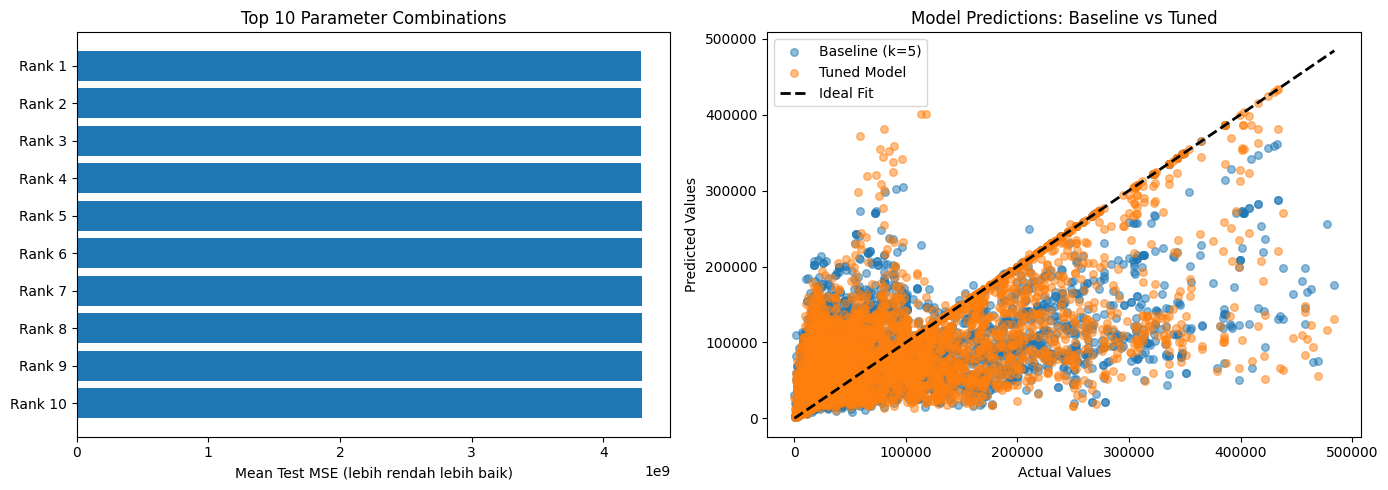


Top 5 Best Parameter Combinations:
1. {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'} | MSE: 4289070883.12
2. {'metric': 'manhattan', 'n_neighbors': 9, 'p': 2, 'weights': 'distance'} | MSE: 4289070883.12
3. {'metric': 'minkowski', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'} | MSE: 4289070883.12
4. {'metric': 'manhattan', 'n_neighbors': 9, 'p': 3, 'weights': 'distance'} | MSE: 4289070883.12
5. {'metric': 'manhattan', 'n_neighbors': 11, 'p': 1, 'weights': 'distance'} | MSE: 4293638656.99


In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_10 = cv_results.head(10)
axes[0].barh(range(len(top_10)), -top_10['mean_test_score'])
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels([f"Rank {i+1}" for i in range(len(top_10))])
axes[0].set_xlabel('Mean Test MSE (lebih rendah lebih baik)')
axes[0].set_title('Top 10 Parameter Combinations')
axes[0].invert_yaxis()

axes[1].scatter(y_test, y_pred_test, alpha=0.5, label='Baseline (k=5)', s=30)
axes[1].scatter(y_test, y_pred_test_tuned, alpha=0.5, label='Tuned Model', s=30)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Model Predictions: Baseline vs Tuned')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nTop 5 Best Parameter Combinations:")
for idx, (i, row) in enumerate(cv_results.head(5).iterrows(), 1):
    params = {k.replace('param_', ''): v for k, v in row.items() if k.startswith('param_')}
    print(f"{idx}. {params} | MSE: {-row['mean_test_score']:.2f}")


In [14]:
y_pred = model.predict(X_test)

In [ ]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'{"Metrik":<10} {"Train":>12} {"Test":>12}')
print(f'{"-"*35}')
print(f'{"MAE":<10} {mae_train:>12.2f} {mae_test:>12.2f}')
print(f'{"RMSE":<10} {rmse_train:>12.2f} {rmse_test:>12.2f}')
print(f'{"R2":<10} {r2_train:>12.4f} {r2_test:>12.4f}')

Metrik            Train         Test
-----------------------------------
MAE            37098.40     46804.06
RMSE           55314.24     68905.64
R2               0.5755       0.3454
